In [3]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter
from sklearn.model_selection import train_test_split

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mateusz/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
df = pd.read_csv("data/all_data.csv")
print(df.columns)

Index(['Unnamed: 0', 'Review_Language', 'City Name', 'Hotel Name',
       'Upside_Review', 'Downside_Review', 'Review_Score', 'Sentiment',
       'source', 'Prompt_Language', 'na_up_review', 'na_down_review'],
      dtype='str')


#### Data Analysis

In [5]:
# restrict analysis to the English language reviews. 
df = df[df["Review_Language"] == "English"].copy()
df["target"] = df["source"].map({0: "Human",1: "AI"})
print(df["target"].value_counts())

target
Human    1000
AI       1000
Name: count, dtype: int64


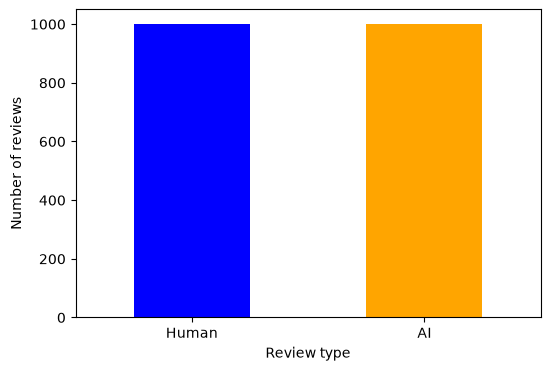

In [6]:
# Data distribution
source_counts = df["source"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
source_counts.plot(kind="bar",color=["blue", "orange"])
plt.xlabel("Review type")
plt.ylabel("Number of reviews")
plt.xticks([0, 1], ["Human", "AI"], rotation=0)
plt.show()

In [7]:
df["Review"] = (df["Upside_Review"].fillna("") + " " +df["Downside_Review"].fillna(""))
df["Review"] = df["Review"].str.strip()

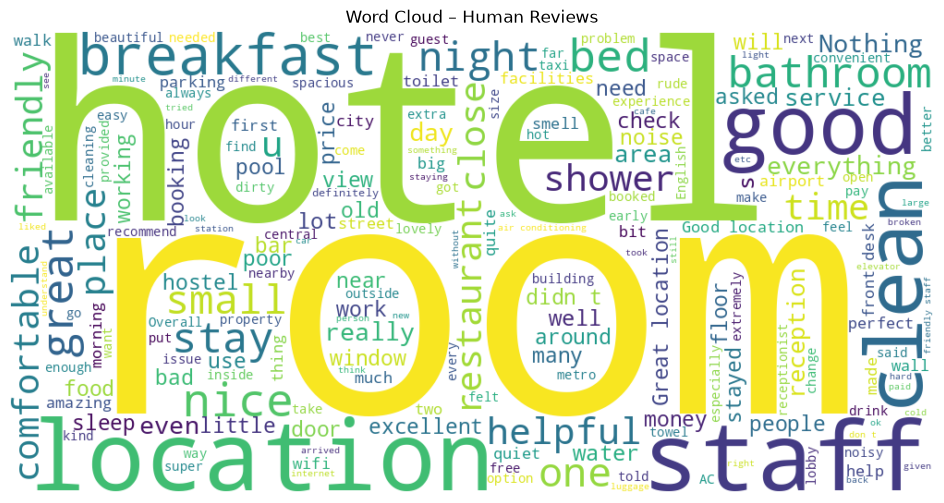

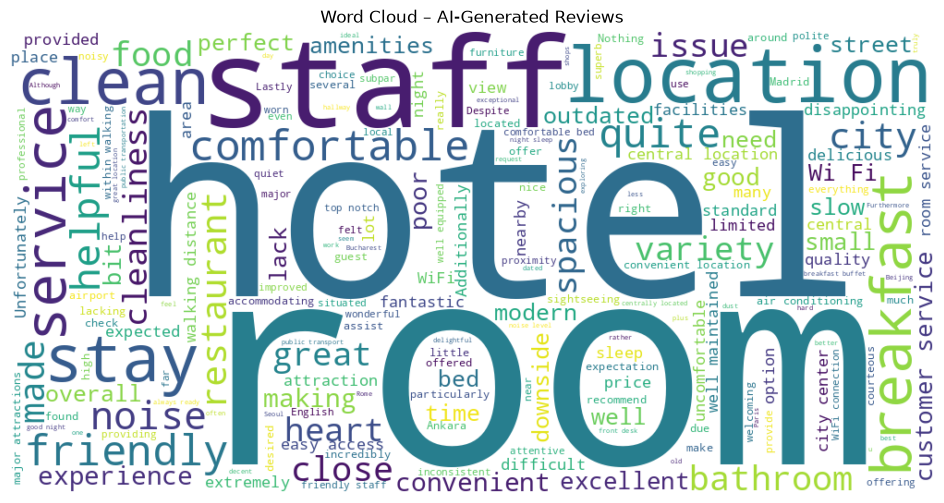

In [8]:
# Word Clouds: visualizing a review's most significant and frequently occurring words.
# Word Cloud Human
human_text = " ".join(df.loc[df["source"] == 0, "Review"].dropna())
wordcloud_human = WordCloud(width=1000, height=500,background_color="white").generate(human_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_human, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Human Reviews")
plt.show()

# Word Cloud Fake
fake_text = " ".join(df.loc[df["source"] == 1, "Review"].dropna())
wordcloud_fake = WordCloud(width=1000, height=500, background_color="white").generate(fake_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_fake, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – AI-Generated Reviews")
plt.show()

In [9]:
def get_words(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

human_words = get_words(" ".join(df.loc[df["source"] == 0, "Review"].dropna()))
fake_words = get_words(" ".join(df.loc[df["source"] == 1, "Review"].dropna()))
human_common = Counter(human_words).most_common(20)
fake_common = Counter(fake_words).most_common(20)
print("Human:", human_common)
print("\nAI:", fake_common)

Human: [('the', 3210), ('and', 1662), ('was', 1344), ('to', 1231), ('a', 1083), ('in', 801), ('room', 743), ('i', 725), ('is', 672), ('of', 620), ('very', 572), ('it', 565), ('for', 541), ('not', 540), ('location', 525), ('hotel', 461), ('staff', 435), ('we', 432), ('good', 354), ('t', 352)]

AI: [('the', 5331), ('and', 2525), ('was', 2176), ('a', 1357), ('to', 1333), ('of', 1029), ('in', 885), ('hotel', 858), ('were', 765), ('location', 726), ('staff', 707), ('is', 656), ('not', 601), ('room', 597), ('rooms', 592), ('with', 589), ('it', 481), ('very', 397), ('for', 378), ('from', 375)]


In [10]:
df["word_count"] = df["Review"].fillna("").str.split().str.len()
print(df["word_count"].describe())

print(df.groupby("source")["word_count"].agg(["count", "mean", "median", "std", "min", "max"]))

count    2000.000000
mean       52.016000
std        43.263375
min         2.000000
25%        22.000000
50%        43.000000
75%        71.000000
max       548.000000
Name: word_count, dtype: float64
        count    mean  median        std  min  max
source                                            
0        1000  48.580    31.5  54.025608    2  548
1        1000  55.452    52.0  28.335677    5  172


In [11]:
pd.crosstab(df["Sentiment"],df["source"],normalize="columns")

source,0,1
Sentiment,,
NEG,0.5,0.5
POS,0.5,0.5


#### Preprocessing  

In [105]:
# three internal processes: Stopword removal, stemming, normalization, and tokenization.
# 1. Normalization: 
# a) Deleting all numbers
# b) Removing all symbols, such as !, ?, #, $, @, *, [ ], { },, =, %, &, (),-, _,;,:-, ", !=, +, ', and /
# c) convert each word to the lowercase (LC)

# 2. Tokenization: divides each review phrase into individual words or tokens. For sentiment analysis.

# 3. Stemming: 
# a) removing stop word: As stop words cannot significantly contribute to the meaning of customer comments.
# b) Porter stemming, word's suffix is being removed in order to return it to its original stem. 


In [12]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess_text(text):
    # 1. Normalization
    text = text.lower()
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Remove symbols and punctuation
    text = re.sub(r"[^a-z\s]", " ", text)
    # Remove multiple whitespaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # 2. Tokenization
    tokens = text.split()
    
    # 3. Stopword removal
    tokens = [word for word in tokens if word not in stop_words]
    
    # 4. Porter stemming
    tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(tokens)

df["Review_clean"] = df["Review"].apply(preprocess_text)

In [13]:
df_model = df[["Review_clean", "source"]].copy()

# check for duplicates
print("duplicate reviews:", df_model["Review_clean"].duplicated().sum())
df_model = df_model.drop_duplicates(subset="Review_clean").copy()
print(df_model.shape)

duplicate reviews: 3
(1997, 2)


In [14]:
df_model = df_model.rename(columns={"Review_clean": "review"})

#### Train/ Test-Split

In [15]:
#  Split the data randomly into a training/validation set (75%) and a test set(25%).
#  Use stratified random sampling so that the class distribution in the training set and test set are the same.

X = df_model["review"]
y = df_model["source"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,stratify=y,random_state=42)

In [16]:
train_df = pd.DataFrame({"review": X_train,"source": y_train})
test_df = pd.DataFrame({"review": X_test,"source": y_test})
train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)